# Exercise 1 — Decision trees and intrinsic interpretability

**PCS956 • Module C • Week 1**

## Research question

**What can we understand directly from a small decision tree, and where do the limits of intrinsic interpretability appear?**

This notebook focuses on direct inspection of a fitted model. We will:

- train a deliberately small decision tree;
- inspect its complete structure and textual rules;
- trace an exact local decision path;
- inspect how leaf probabilities are obtained;
- study complexity versus predictive performance;
- examine structural stability under resampling.

No post-hoc explainer is used here.


## Dataset: Titanic

We use the same Titanic passenger dataset throughout all four Week 1 practical notebooks so that the **data remain fixed while the explanation question changes**.

Each row represents one passenger. The target is:

- `survived = 1` — the passenger was recorded as surviving;
- `survived = 0` — the passenger was recorded as not surviving.

We use these predictors:

| Feature | Meaning |
|---|---|
| `pclass` | Passenger class: 1st, 2nd, or 3rd |
| `sex` | Recorded sex |
| `age` | Age in years |
| `sibsp` | Number of siblings/spouses aboard |
| `parch` | Number of parents/children aboard |
| `fare` | Passenger fare |
| `embarked` | Port of embarkation |

The seaborn version of the dataset contains missing values, including missing `age` and `embarked` values. Preprocessing is therefore fitted **only on the training data** and then applied to the test data.

### Scientific caution

This is historical observational data. These notebooks investigate **model behaviour**. Feature importance, decision rules, and SHAP attributions should not be interpreted as causal effects on survival.


## 1. Setup and preprocessing

The same preprocessing pipeline will be reused in all Week 1 notebooks.

- numeric missing values are imputed with the training-set median;
- categorical missing values are imputed with the training-set mode;
- categorical variables are one-hot encoded;
- binary `sex` is encoded with one non-redundant indicator;
- the train/test split is stratified and fixed with `RANDOM_STATE = 42`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

RANDOM_STATE = 42

titanic = sns.load_dataset("titanic")

FEATURES = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]
TARGET = "survived"

X = titanic[FEATURES].copy()
y = titanic[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="if_binary"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names,
    index=X_train_raw.index
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names,
    index=X_test_raw.index
)

print("Training observations:", len(X_train_df))
print("Test observations:", len(X_test_df))
print("Transformed features:", list(feature_names))


Training observations: 712
Test observations: 179
Transformed features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


### Discuss the preprocessing output

Check the transformed feature names carefully.

The model will operate on these transformed columns, so explanations refer to the **model representation** rather than automatically to the original raw variables. For example, `embarked` becomes separate indicator columns.


## 2. Train a small decision tree

We set `max_depth=3` deliberately. The aim is to preserve direct global inspectability, not to claim that depth 3 is predictively optimal.


In [2]:
tree_small = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

tree_small.fit(X_train_df, y_train)

train_pred = tree_small.predict(X_train_df)
test_pred = tree_small.predict(X_test_df)

print("Training accuracy:",
      round(accuracy_score(y_train, train_pred), 3))
print("Test accuracy:",
      round(accuracy_score(y_test, test_pred), 3))
print("Test balanced accuracy:",
      round(balanced_accuracy_score(y_test, test_pred), 3))

print("\nTree depth:", tree_small.get_depth())
print("Number of nodes:", tree_small.tree_.node_count)
print("Number of leaves:", tree_small.get_n_leaves())


Training accuracy: 0.833
Test accuracy: 0.793
Test balanced accuracy: 0.748

Tree depth: 3
Number of nodes: 15
Number of leaves: 8


### Discuss the result

Use the output to answer two separate questions:

1. **Predictive performance:** How well does the tree perform on the held-out test data?
2. **Structural complexity:** Is a depth-3 tree with the reported number of nodes still practical to inspect globally?

A training–test performance gap may be worth investigating, but the gap alone is not sufficient evidence to declare overfitting.


## 3. Global intrinsic interpretation

The entire small tree gives a **global view of the fitted model's rule structure**.


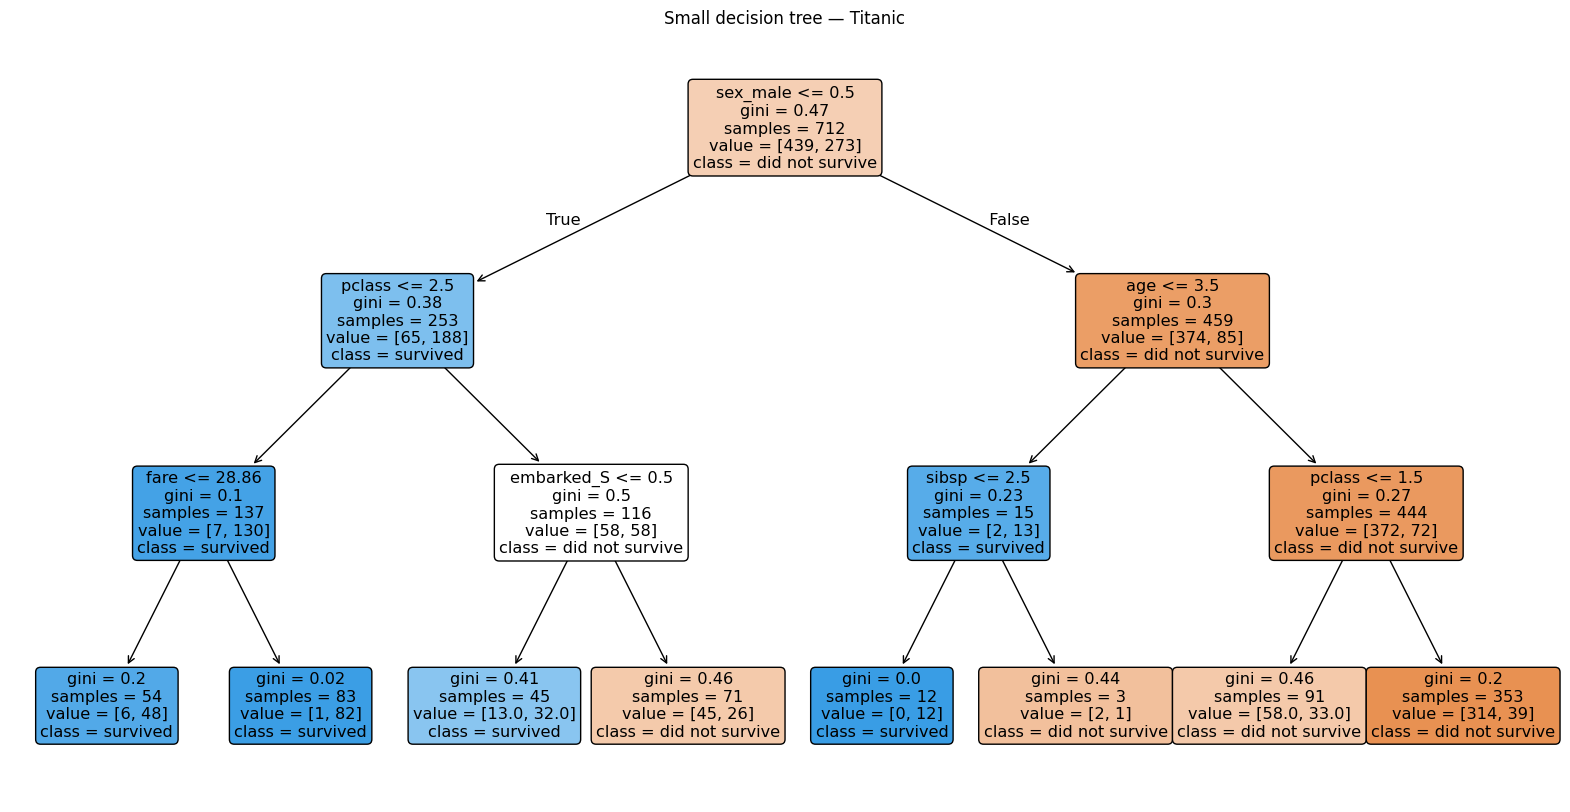

In [3]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_small,
    feature_names=feature_names,
    class_names=["did not survive", "survived"],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2
)

plt.title("Small decision tree — Titanic")
plt.show()


### Discuss the tree

Identify:

- the root feature and threshold;
- the features that appear repeatedly;
- leaves that contain mixed classes;
- features that do not appear anywhere in the small tree.

These observations describe this **fitted tree**, not universal facts about Titanic survival.


## 4. Inspect the exact rules as text

The following rules are part of the predictive model itself; they are not a post-hoc approximation.


In [4]:
print(
    export_text(
        tree_small,
        feature_names=list(feature_names),
        decimals=2
    )
)


|--- sex_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 28.86
|   |   |   |--- class: 1
|   |   |--- fare >  28.86
|   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- embarked_S <= 0.50
|   |   |   |--- class: 1
|   |   |--- embarked_S >  0.50
|   |   |   |--- class: 0
|--- sex_male >  0.50
|   |--- age <= 3.50
|   |   |--- sibsp <= 2.50
|   |   |   |--- class: 1
|   |   |--- sibsp >  2.50
|   |   |   |--- class: 0
|   |--- age >  3.50
|   |   |--- pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- pclass >  1.50
|   |   |   |--- class: 0



### Discuss the rules

Ask whether the textual representation is easier to audit than the plotted tree.

A rule involving `pclass`, `sex_male`, `fare`, or another feature states how the fitted model partitions its input space. It does **not** establish that intervening on that feature would causally change survival.


## 5. Explain one prediction with an exact decision path

To make the distinction between interpretability and correctness concrete, the code below selects a **misclassified test passenger if one exists**. Among misclassified cases, it chooses one with a relatively long path. If the model happens to make no errors, it falls back to the deepest available test path.


In [5]:
path_lengths = tree_small.decision_path(X_test_df).sum(axis=1).A1
misclassified_positions = np.flatnonzero(
    test_pred != y_test.to_numpy()
)

if len(misclassified_positions) > 0:
    sample_position = int(
        misclassified_positions[
            np.argmax(path_lengths[misclassified_positions])
        ]
    )
    selection_reason = "misclassified test case"
else:
    sample_position = int(np.argmax(path_lengths))
    selection_reason = "deepest available test path"

sample = X_test_df.iloc[[sample_position]]
raw_sample = X_test_raw.iloc[[sample_position]]

true_class = int(y_test.iloc[sample_position])
predicted_class = int(tree_small.predict(sample)[0])
probabilities = tree_small.predict_proba(sample)[0]

print("Selected:", selection_reason)
display(raw_sample)

print("Observed outcome:",
      "survived" if true_class == 1 else "did not survive")
print("Predicted outcome:",
      "survived" if predicted_class == 1 else "did not survive")
print("Predicted probabilities:")
print("  did not survive:", round(probabilities[0], 3))
print("  survived:", round(probabilities[1], 3))


Selected: misclassified test case


,pclass,sex,age,sibsp,parch,fare,embarked
553,3,male,22.0,0,0,7.225,C


Observed outcome: survived
Predicted outcome: did not survive
Predicted probabilities:
  did not survive: 0.89
  survived: 0.11


In [6]:
node_indicator = tree_small.decision_path(sample)
leaf_id = tree_small.apply(sample)[0]
tree = tree_small.tree_

print("Exact decision path:\n")

for node_id in node_indicator.indices:
    if node_id == leaf_id:
        print(
            f"Node {node_id}: LEAF → prediction = "
            f"{'survived' if predicted_class == 1 else 'did not survive'}"
        )
    else:
        feature_index = tree.feature[node_id]
        threshold = tree.threshold[node_id]
        feature_name = feature_names[feature_index]
        feature_value = sample.iloc[0, feature_index]

        relation = "<=" if feature_value <= threshold else ">"

        print(
            f"Node {node_id}: {feature_name} = {feature_value:.3f} "
            f"{relation} {threshold:.3f}"
        )


Exact decision path:

Node 0: sex_male = 1.000 > 0.500
Node 8: age = 22.000 > 3.500
Node 12: pclass = 3.000 > 1.500
Node 14: LEAF → prediction = did not survive


### Discuss the local result

The path is an **exact description of the rules used by this fitted tree for this prediction**.

If the selected case is misclassified, that gives an important result:

> An explanation can be exact with respect to the model and the prediction can still be wrong.

The path is local; it should not be generalized to the whole tree.


## 6. Where do the class probabilities come from?

For a classification tree, `predict_proba` is based on the class proportions among the training observations that reach the corresponding leaf.


In [7]:
leaf_node = tree_small.apply(sample)[0]
train_leaf_ids = tree_small.apply(X_train_df)

same_leaf = train_leaf_ids == leaf_node
leaf_targets = y_train.to_numpy()[same_leaf]

count_0 = np.sum(leaf_targets == 0)
count_1 = np.sum(leaf_targets == 1)
total = len(leaf_targets)

leaf_table = pd.DataFrame({
    "class": ["did not survive", "survived"],
    "training_count_in_leaf": [count_0, count_1],
    "leaf_proportion": [count_0 / total, count_1 / total]
})

display(leaf_table)
print("Model probabilities:", np.round(probabilities, 3))


,class,training_count_in_leaf,leaf_proportion
0,did not survive,314,0.889518
1,survived,39,0.110482


Model probabilities: [0.89 0.11]


### Discuss the probability output

Verify that the class proportions in the leaf match the model probabilities.

This calculation is transparent, but transparency does not establish that these probabilities are calibrated for unseen populations or future data.


## 7. Complexity experiment

We now vary tree depth and compare predictive performance with structural complexity.


In [8]:
depth_values = [1, 2, 3, 4, 5, 6, 8, None]
records = []

for max_depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_df, y_train)

    train_predictions = model.predict(X_train_df)
    test_predictions = model.predict(X_test_df)

    records.append({
        "max_depth": "None" if max_depth is None else str(max_depth),
        "fitted_depth": model.get_depth(),
        "nodes": model.tree_.node_count,
        "leaves": model.get_n_leaves(),
        "train_accuracy": accuracy_score(y_train, train_predictions),
        "test_accuracy": accuracy_score(y_test, test_predictions),
        "test_balanced_accuracy": balanced_accuracy_score(
            y_test, test_predictions
        )
    })

complexity_results = pd.DataFrame(records)
display(complexity_results)


,max_depth,fitted_depth,nodes,leaves,train_accuracy,test_accuracy,test_balanced_accuracy
0,1,1,3,2,0.789326,0.776536,0.753360
1,2,2,7,4,0.804775,0.759777,0.701910
2,3,3,15,8,0.832865,0.793296,0.748090
3,4,4,29,15,0.841292,0.787709,0.743544
4,5,5,45,23,0.865169,0.776536,0.747958
5,6,6,69,35,0.886236,0.804469,0.767984
6,8,8,127,64,0.921348,0.798883,0.771542
7,None,23,303,152,0.983146,0.826816,0.813175


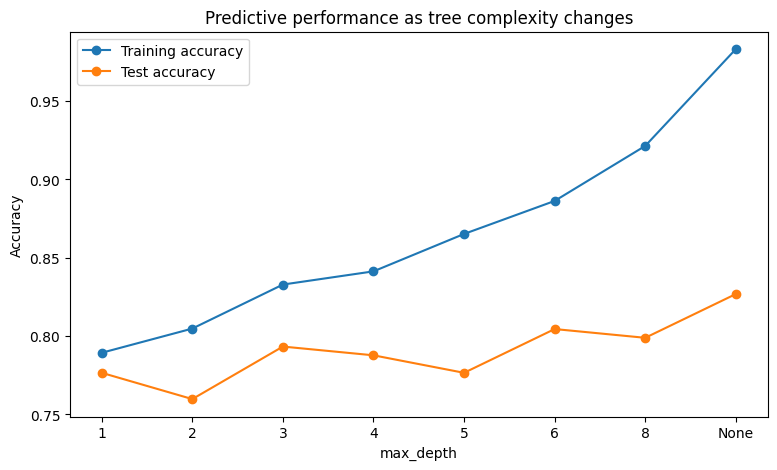

In [9]:
x = np.arange(len(complexity_results))

plt.figure(figsize=(9, 5))
plt.plot(x, complexity_results["train_accuracy"],
         marker="o", label="Training accuracy")
plt.plot(x, complexity_results["test_accuracy"],
         marker="o", label="Test accuracy")
plt.xticks(x, complexity_results["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Predictive performance as tree complexity changes")
plt.legend()
plt.show()


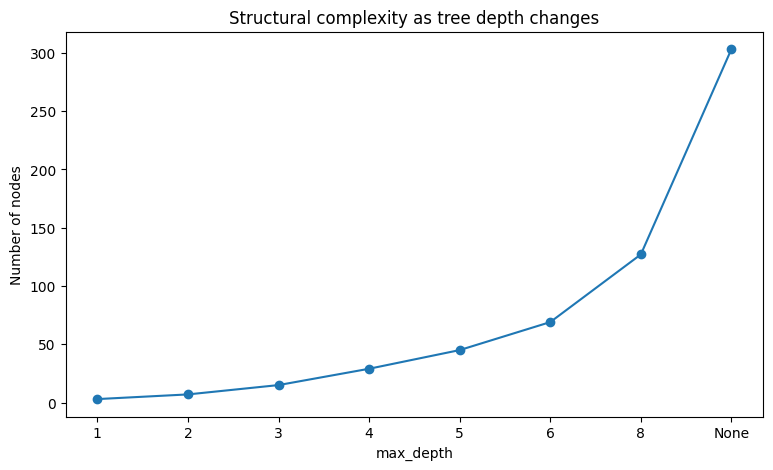

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(x, complexity_results["nodes"], marker="o")
plt.xticks(x, complexity_results["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("Number of nodes")
plt.title("Structural complexity as tree depth changes")
plt.show()


### Discuss the complexity results

Look for three patterns:

- training accuracy will often improve or stay unchanged as the tree becomes more flexible;
- test accuracy need not improve monotonically;
- the number of nodes can increase rapidly even when test performance changes little.

Therefore, the experiment should **not** be summarized as a universal accuracy–interpretability trade-off. It shows a problem-specific relationship between complexity, performance, and inspectability.


## 8. Stability experiment

Intrinsic interpretability tells us that a fitted tree can be inspected. It does not imply that essentially the same tree would be learned from a slightly different training sample.


,root_feature,count
0,sex_male,30


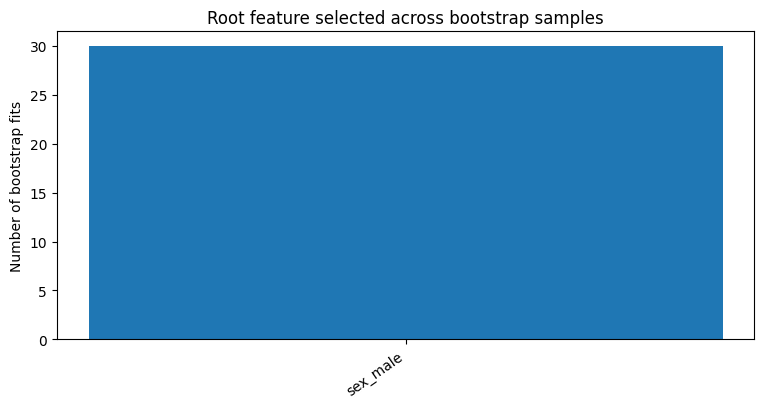

In [11]:
rng = np.random.default_rng(RANDOM_STATE)
stability_records = []

for run in range(30):
    bootstrap_positions = rng.integers(
        0,
        len(X_train_df),
        size=len(X_train_df)
    )

    X_boot = X_train_df.iloc[bootstrap_positions]
    y_boot = y_train.iloc[bootstrap_positions]

    model = DecisionTreeClassifier(
        max_depth=3,
        random_state=run
    )
    model.fit(X_boot, y_boot)

    root_feature_index = model.tree_.feature[0]

    # A fitted tree can, in principle, contain no split. In scikit-learn,
    # a leaf node has feature index -2, so handle that case explicitly.
    if root_feature_index >= 0:
        root_feature = feature_names[root_feature_index]
        root_threshold = model.tree_.threshold[0]
    else:
        root_feature = "no split"
        root_threshold = np.nan

    stability_records.append({
        "run": run,
        "root_feature": root_feature,
        "root_threshold": root_threshold
    })

stability_results = pd.DataFrame(stability_records)

root_summary = (
    stability_results["root_feature"]
    .value_counts()
    .rename_axis("root_feature")
    .reset_index(name="count")
)

display(root_summary)

plt.figure(figsize=(9, 4))
plt.bar(root_summary["root_feature"], root_summary["count"])
plt.ylabel("Number of bootstrap fits")
plt.title("Root feature selected across bootstrap samples")
plt.xticks(rotation=35, ha="right")
plt.show()


### Discuss the stability result

If the same root feature appears in all runs, the root choice is relatively stable under this bootstrap experiment.

If several features appear, the fitted root rule is sample-sensitive.

Either outcome is informative. **Interpretability and stability are distinct properties.**


## Student task

1. Change the tree depth (for example, compare `max_depth=2` and `max_depth=4`).
2. Compare test performance and the number of nodes.
3. Select a different test passenger and trace the exact decision path.
4. Write 3–4 sentences answering:

   - Did the deeper tree become harder to inspect?
   - Did predictive performance necessarily improve?
   - What does the local path explain exactly?
   - Why does an exact explanation of the fitted tree not guarantee that the prediction is correct?

Keep your conclusions specific to the fitted models and this dataset.


## 9. Critical discussion

1. Does an exact decision path explain the historical event itself, or only the fitted model's prediction?
2. Can a fully transparent tree still be wrong?
3. How should instability across bootstrap refits affect confidence in a particular rule?
4. At what model size would you stop calling the tree practically globally interpretable?
5. What evidence beyond interpretability would be needed in a consequential application?


## 10. Takeaway

A small decision tree illustrates **intrinsic interpretability** because its learned structure can be inspected directly.

- the whole tree gives a global view;
- the root-to-leaf path gives an exact local model description;
- complexity can make global inspection difficult;
- transparency does not establish correctness, stability, causality, calibration, or suitability for deployment.
